[INFO] Dataset loaded successfully! Shape: (4600, 10)
[INFO] Dataset cleaned (removed 0-price rows). New Shape: (4551, 10)
[INFO] Model training completed successfully.

================ EVALUATION METRICS ================
Mean Absolute Error (MAE)  : $162,962.34
Root Mean Squared Error (RMSE): $264,481.97


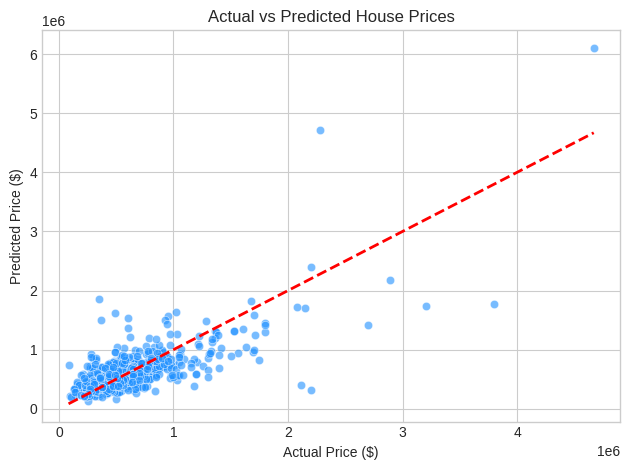

[INFO] Plot saved to your environment as 'actual_vs_predicted_cleaned.png'


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. LOAD DATASET
# Make sure 'House Price Prediction.csv' is uploaded to your Colab sidebar
file_name = 'House Price Prediction.csv'
df = pd.read_csv(file_name)
print(f"[INFO] Dataset loaded successfully! Shape: {df.shape}")

# 2. PREPROCESSING & CLEANING
# Removing rows where price is 0 (data errors)
df_clean = df[df['price'] > 0]
print(f"[INFO] Dataset cleaned (removed 0-price rows). New Shape: {df_clean.shape}")

# Selecting features and target based on your specific columns
features = ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition']
target = 'price'

X = df_clean[features]
y = df_clean[target]

# 3. TRAIN-TEST SPLIT (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. FEATURE SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. MODEL TRAINING (Gradient Boosting Regressor)
model = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=4, random_state=42)
model.fit(X_train_scaled, y_train)
print("[INFO] Model training completed successfully.")

# 6. MAKING PREDICTIONS & EVALUATION
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n================ EVALUATION METRICS ================")
print(f"Mean Absolute Error (MAE)  : ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print("====================================================")

# 7. VISUALIZATION (Actual vs Predicted Prices)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='dodgerblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2, linestyle='--')
plt.title('Actual vs Predicted House Prices')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.grid(True)
plt.tight_layout()

# Save the plot image to your local directory
plt.savefig('actual_vs_predicted_cleaned.png')
plt.show()
print("[INFO] Plot saved to your environment as 'actual_vs_predicted_cleaned.png'")